# EDA и анализ данных

Вывод информации о данных для проверки

In [ ]:
print("Информация о данных:")
print(data.info())
print("\nПервые 5 строк данных:")
print(data.head())


Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1528103 entries, 0 to 1528102
Data columns (total 19 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   researchDate               1528103 non-null  datetime64[ns]
 1   researchDayType            1528103 non-null  object        
 2   tvCompanyId                1528103 non-null  int64         
 3   tvCompanyName              1528103 non-null  object        
 4   breaksSpotId               1528103 non-null  int64         
 5   breaksStartTime            1528103 non-null  object        
 6   breaksFinishTime           1528103 non-null  object        
 7   breaksDuration             1528103 non-null  int64         
 8   breaksPrimeTimeStatusName  1528101 non-null  object        
 9   programFirstIssueDate      1528103 non-null  object        
 10  programAgeRestrictionName  1320534 non-null  object        
 11  programName     

Преобразование researchDate в datetime


In [ ]:
data['researchDate'] = pd.to_datetime(data['researchDate'])

Проверка столбца breaksStartTime перед преобразованием


In [ ]:
print("\nПроверка breaksStartTime:")
print(data['breaksStartTime'].head())
print("Тип данных breaksStartTime:", data['breaksStartTime'].dtype)


Проверка breaksStartTime:
0    00:13:56
1    00:30:02
2    01:12:22
3    01:25:39
4    01:55:19
Name: breaksStartTime, dtype: object
Тип данных breaksStartTime: object


Преобразование breaksStartTime в datetime для извлечения временных компонент и создание столбцов для часа, минут и секунд


In [ ]:
try:

    dt_series = pd.to_datetime(data['breaksStartTime'], format='%H:%M:%S', errors='coerce')

    data['hour'] = dt_series.dt.hour
    data['minute'] = dt_series.dt.minute
    data['second'] = dt_series.dt.second

    print("Успешно созданы столбцы с временными компонентами:")
    print(data[['breaksStartTime', 'hour', 'minute', 'second']].head())

except ValueError as e:
    print(f"Ошибка при преобразовании breaksStartTime: {e}")
    problematic_rows = data[~data['breaksStartTime'].str.match(r'^\d{2}:\d{2}:\d{2}$', na=False)]
    print("Проблемные строки в breaksStartTime:")
    print(problematic_rows[['breaksStartTime']])

Успешно созданы столбцы с временными компонентами:
  breaksStartTime  hour  minute  second
0        00:13:56     0      13      56
1        00:30:02     0      30       2
2        01:12:22     1      12      22
3        01:25:39     1      25      39
4        01:55:19     1      55      19


Обработка researchDate в datetime для извлечения даты напрямую


In [ ]:
try:
    dt_series = pd.to_datetime(data['researchDate'], format='%Y-%m-%d', errors='coerce')

    data['day'] = dt_series.dt.day
    data['month'] = dt_series.dt.month

    print("\nУспешно созданы столбцы с датой:")
    print(data[['researchDate', 'day', 'month']].head())

except ValueError as e:
    print(f"Ошибка при преобразовании researchDate: {e}")
    problematic_rows = data[~data['researchDate'].str.match(r'^\d{4}-\d{2}-\d{2}$', na=False)]
    print("Проблемные строки в researchDate:")
    print(problematic_rows[['researchDate']])


Успешно созданы столбцы с датой:
  researchDate  day  month
0   2020-01-01    1      1
1   2020-01-01    1      1
2   2020-01-01    1      1
3   2020-01-01    1      1
4   2020-01-01    1      1


## Анализ пропусков



Столбцы с пропущенными значениями:
breaksPrimeTimeStatusName          2
programAgeRestrictionName     207569
SalesRtgPer                    22870
predictions                  1528103
dtype: int64


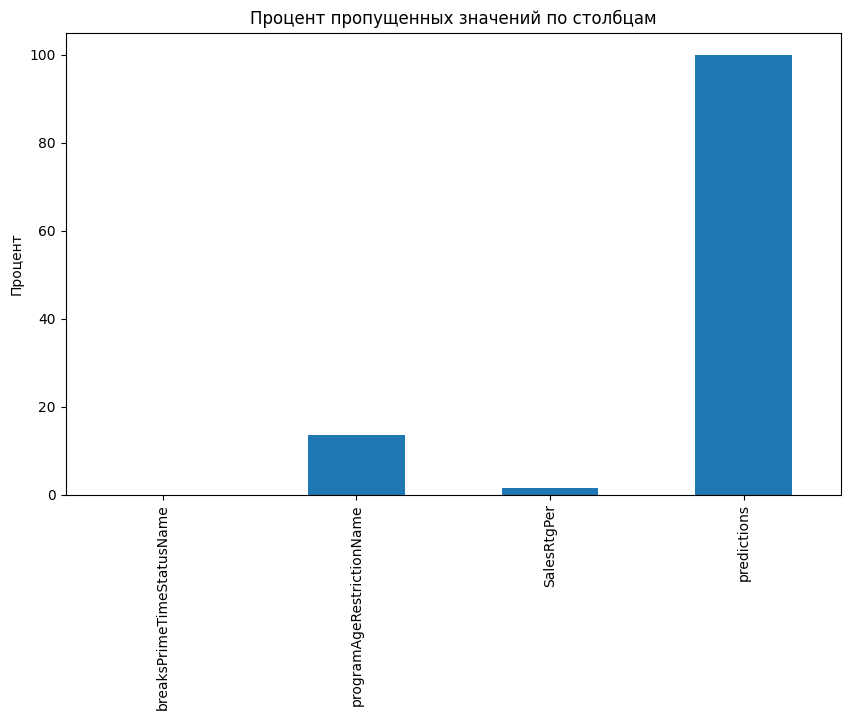

In [ ]:
missing_values = data.isnull().sum()
print("\nСтолбцы с пропущенными значениями:")
print(missing_values[missing_values > 0])

missing_percentage = (data.isnull().sum() / len(data)) * 100
missing_percentage = missing_percentage[missing_percentage > 0]
plt.figure(figsize=(10, 6))
missing_percentage.plot(kind='bar')
plt.title('Процент пропущенных значений по столбцам')
plt.ylabel('Процент')
plt.show()

Этот график показывает долю пропущенных данных в трёх столбцах:

programAgeRestrictionName: ~13–14% пропусков (возрастное ограничение программы).
SalesRtgPer: ~1–2% пропусков (рейтинг рекламного блока).
breaksPrimeTimeStatusName: Пропуски минимальны (всего 2 записи).

Анализ выбросов для SalesRtgPer


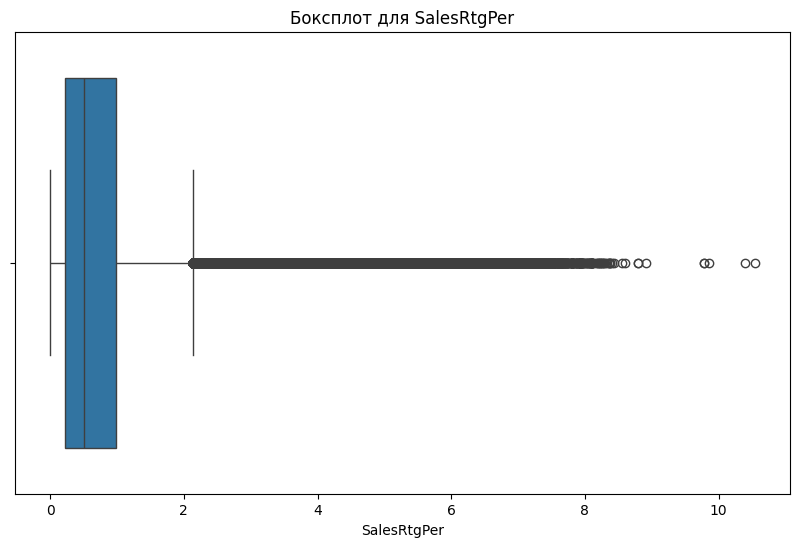

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=data['SalesRtgPer'])
plt.title('Боксплот для SalesRtgPer')
plt.show()

Этот график (ящик с усами) показывает распределение значений рейтинга рекламного блока (SalesRtgPer). Основная часть данных находится в диапазоне от 0 до 1.5, с медианой около 0.7–0.8. Однако есть значительное количество выбросов — 82,438 значений (около 5.4% данных), где SalesRtgPer превышает 2, достигая значений до 10. Эти выбросы могут указывать на редкие пики популярности программ или рекламы, но также могут искажать средние показатели.

Метод IQR для SalesRtgPer


In [ ]:
Q1 = data['SalesRtgPer'].quantile(0.25)
Q3 = data['SalesRtgPer'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = data[(data['SalesRtgPer'] < lower_bound) | (data['SalesRtgPer'] > upper_bound)]
print(f"Количество выбросов в SalesRtgPer: {len(outliers)}")

Количество выбросов в SalesRtgPer: 82438


## Анализ трендов

Средний SalesRtgPer по дате


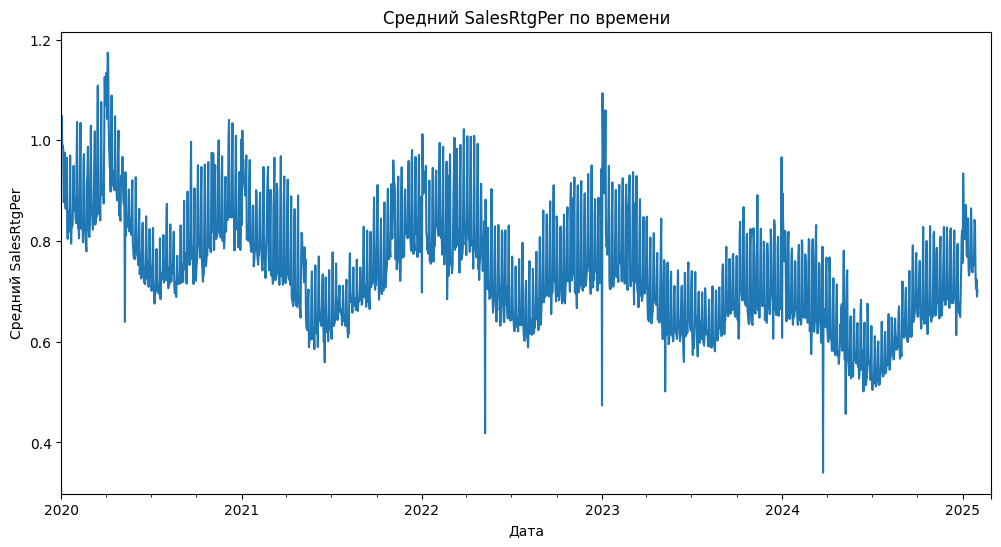

In [ ]:
plt.figure(figsize=(12, 6))
data.groupby('researchDate')['SalesRtgPer'].mean().plot()
plt.title('Средний SalesRtgPer по времени')
plt.xlabel('Дата')
plt.ylabel('Средний SalesRtgPer')
plt.show()

Этот график показывает средний рейтинг рекламного блока (SalesRtgPer) по дням с 2020 по 2025 год.

Наблюдаются регулярные колебания с пиками и спадами, что может быть связано с сезонностью (например, праздничные периоды).
Общий тренд: средний рейтинг снижается с 2020 года (около 0.9) до 2025 года (около 0.6), что указывает на долгосрочное снижение популярности рекламы или программ.
Есть заметные провалы (например, в 2022 и 2024 годах), которые могут быть связаны с внешними факторами.

SalesRtgPer по часам дня


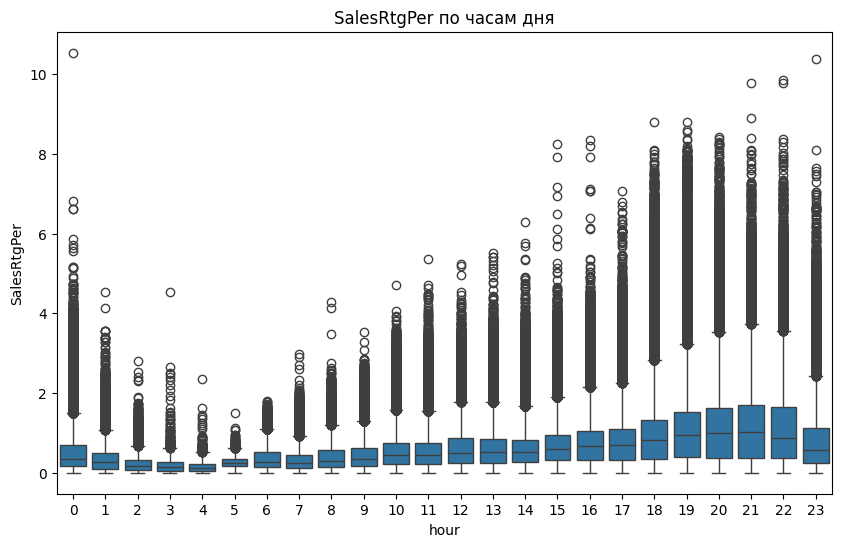

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='hour', y='SalesRtgPer', data=data)
plt.title('SalesRtgPer по часам дня')
plt.show()

Этот график (ящик с усами) показывает, как рейтинг рекламного блока (SalesRtgPer) меняется в зависимости от времени суток (0–23 часа).

Самые высокие рейтинги рекламных блоков наблюдаются в вечерние часы (18:00–22:00), особенно в 20:00–21:00, где медиана достигает около 1.5. Это означает, что реклама в это время охватывает наибольшую аудиторию.
Низкие рейтинги — ночью и утром (0:00–6:00), с медианой около 0.5, что говорит о минимальном охвате аудитории в эти часы.
В вечерние часы больше выбросов (значения до 10), что указывает на редкие пики охвата, возможно, связанные с популярными программами или событиями.

Влияние типа дня


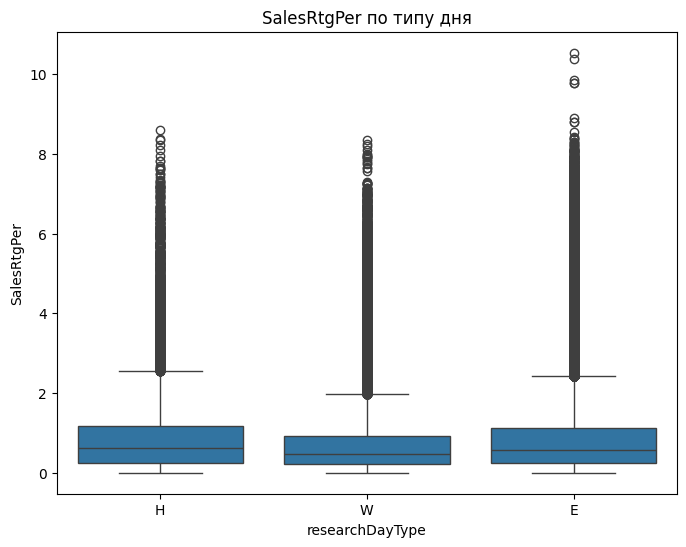

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='researchDayType', y='SalesRtgPer', data=data)
plt.title('SalesRtgPer по типу дня')
plt.show()

Этот график (ящик с усами) показывает, как рейтинг рекламного блока (SalesRtgPer) зависит от типа дня: H (праздничный), W (рабочий), E (выходной).

Медианный рейтинг рекламного блока примерно одинаков для всех типов дней (около 0.7–0.8), что говорит о схожем охвате аудитории.
В праздничные дни (H) больше выбросов (значения до 10), что указывает на редкие пики охвата, вероятно, связанные с популярными событиями или программами.
В рабочие (W) и выходные (E) дни рейтинги более стабильны, без значительных всплесков.

Сравнение до и после 2024 года



Средний SalesRtgPer до 2024: 0.7620910096540825
Средний SalesRtgPer с 2024: 0.6581868993334634


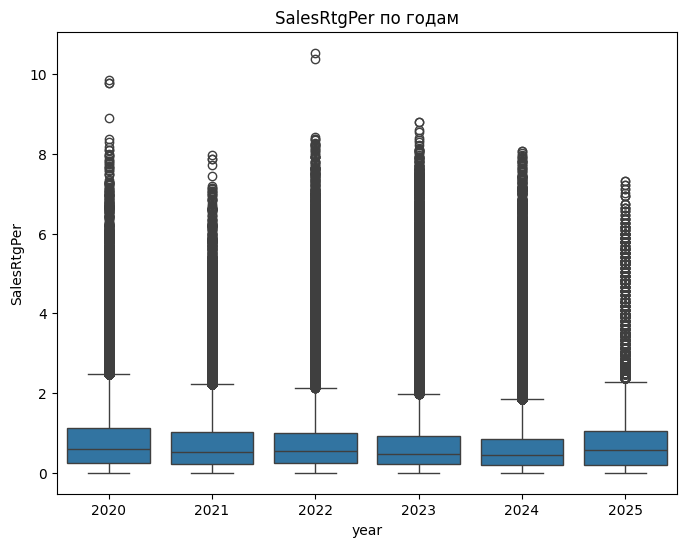

In [ ]:
data['year'] = data['researchDate'].dt.year
pre_2024 = data[data['year'] < 2024]
post_2024 = data[data['year'] >= 2024]
print("\nСредний SalesRtgPer до 2024:", pre_2024['SalesRtgPer'].mean())
print("Средний SalesRtgPer с 2024:", post_2024['SalesRtgPer'].mean())

plt.figure(figsize=(8, 6))
sns.boxplot(x='year', y='SalesRtgPer', data=data)
plt.title('SalesRtgPer по годам')
plt.show()

Этот график (ящик с усами) показывает распределение рейтинга рекламного блока (SalesRtgPer) по годам с 2020 по 2025.

Медианный рейтинг постепенно снижается: с ~0.8 в 2020 году до ~0.6 в 2025 году, что указывает на долгосрочное снижение охвата аудитории.
Средний рейтинг до 2024 года составляет 0.762, а с 2024 года — 0.658, подтверждая тенденцию к снижению.
В каждом году есть выбросы (значения до 10), что говорит о редких пиках охвата, возможно, связанных с крупными событиями или популярными программами.

Сравнение декабря 2024 года и января 2024 года с отсльным временем